In [2]:
import networkx as nx 
import network_models as nm
import nx_tools as nxt
import pickle
import pandas as pd
import numpy as np

# PyTorch and PyTorch Geometric imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx

# Sklearn imports
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

Goal for the GNN: Predict whether a building increased in height from 2016 to 2023, based on its features and surrounding buildings.

In [2]:
#with open('/Users/srutman/Library/CloudStorage/OneDrive-BowdoinCollege/Documents/DSAN6400/Dakar_networks/output/building_network_2016.pkl', 'rb') as f:
with open('/Users/rachnarawalpally/Dakar_networks/output/building_network_2016.pkl', 'rb') as f:
    G_full = pickle.load(f)

# Check what you got
# Extract a smaller subgraph (e.g., first 1000 nodes)
nodes_subset = list(G_full.nodes())[:1000]
G = G_full.subgraph(nodes_subset).copy() 

In [3]:
# Load 2016 and 2023 building graphs
with open("/Users/rachnarawalpally/Dakar_networks/output/building_network_2016.pkl", "rb") as f:
    G_2016 = pickle.load(f)

with open("/Users/rachnarawalpally/Dakar_networks/output/building_network_2023.pkl", "rb") as f:
    G_2023 = pickle.load(f)

In [4]:
list(G_2016.nodes(data=True))[:5]

[(0,
  {'geometry': <POLYGON ((-3119275.012 1936415.749, -3119276.496 1936406.596, -3119272.047 ...>,
   'mean_presence': 0.5981249809265137,
   'mean_height': 2.9192708333333335,
   'LandUseClass': 'Other',
   'area': 62.69363569840901}),
 (1,
  {'geometry': <POLYGON ((-3119285.395 1936408.039, -3119286.137 1936403.463, -3119281.688 ...>,
   'mean_presence': 0.3568750023841858,
   'mean_height': 1.625,
   'LandUseClass': 'Other',
   'area': 20.89792425320416}),
 (2,
  {'geometry': <POLYGON ((-3119262.406 1936409.008, -3119263.148 1936404.431, -3119267.598 ...>,
   'mean_presence': 0.6175781091054281,
   'mean_height': 4.072916666666667,
   'LandUseClass': 'Other',
   'area': 250.77403608282697}),
 (3,
  {'geometry': <POLYGON ((-3119283.173 1936393.588, -3119283.915 1936389.012, -3119288.364 ...>,
   'mean_presence': 0.5595624923706055,
   'mean_height': 2.8375,
   'LandUseClass': 'Other',
   'area': 104.48966520609737}),
 (4,
  {'geometry': <POLYGON ((-3119277.243 1936373.839, -311927

In [4]:
# Convert to DataFrames
df_2016 = pd.DataFrame.from_dict(dict(G_2016.nodes(data=True)), orient='index')
df_2023 = pd.DataFrame.from_dict(dict(G_2023.nodes(data=True)), orient='index')

# Merge 2023 height into 2016 data
df_2016['mean_height_2023'] = df_2023['mean_height']

# Compute label: did height increase > 1m?
df_2016['label'] = (df_2016['mean_height_2023'] - df_2016['mean_height']) > 1.0
df_2016['label'] = df_2016['label'].astype(int)

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Pick your feature columns
feature_cols = ['mean_height', 'mean_presence', 'area']
df_2016[feature_cols] = df_2016[feature_cols].fillna(0)
# Add LandUseClass column to df_2016
df_2016['LandUseClass'] = pd.Series(nx.get_node_attributes(G_2016, 'LandUseClass'))
# One-hot encode
df_2016 = pd.get_dummies(df_2016, columns=['LandUseClass'])
# Degree (number of neighbors)
degree_dict = dict(G_2016.degree())
df_2016['degree'] = pd.Series(degree_dict)

# Clustering coefficient
clustering_dict = nx.clustering(G_2016)
df_2016['clustering'] = pd.Series(clustering_dict)
feature_cols = ['mean_height', 'mean_presence', 'area', 'degree', 'clustering'] + \
               [col for col in df_2016.columns if col.startswith('LandUseClass_')]
# Add to feature columns
# too large to compute 
# df_2016['degree_centrality'] = pd.Series(nx.degree_centrality(G_2016))
# #df_2016['betweenness_centrality'] = pd.Series(nx.betweenness_centrality(G_2016, k=1000, seed=42))
# df_2016['closeness_centrality'] = pd.Series(nx.closeness_centrality(G_2016))

# # Add to your feature list
# feature_cols += ['degree_centrality','closeness_centrality']

# Normalize all features again
scaler = MinMaxScaler()
df_2016[feature_cols] = scaler.fit_transform(df_2016[feature_cols])


In [6]:
for n in G_2016.nodes():
    for col in feature_cols:
        G_2016.nodes[n][col] = float(df_2016.loc[n, col])
    G_2016.nodes[n]['label'] = int(df_2016.loc[n, 'label'])


In [8]:
from torch_geometric.utils import from_networkx

In [9]:
print(df_2016[feature_cols].shape)
print(df_2016[feature_cols].isna().sum().sum())
print(set(G_2016.nodes) == set(df_2016.index))

(101789, 9)
0
True


In [7]:

data = from_networkx(G_2016)
data.x = torch.tensor(df_2016[feature_cols].values, dtype=torch.float32)
data.y = torch.tensor(df_2016['label'].values, dtype=torch.long)


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn

In [ ]:
# 2 - layer 
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x
# 3-layer 
# class GCN(torch.nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super().__init__()
#         self.conv1 = GCNConv(in_channels, hidden_channels)
#         self.conv2 = GCNConv(hidden_channels, hidden_channels)
#         self.conv3 = GCNConv(hidden_channels, out_channels)
#         self.dropout = nn.Dropout(0.3)

#     def forward(self, data):
#         x, edge_index = data.x, data.edge_index
#         x = F.relu(self.conv1(x, edge_index))
#         x = self.dropout(x)
#         x = F.relu(self.conv2(x, edge_index))
#         x = self.dropout(x)
#         x = self.conv3(x, edge_index)
#         return x
# want better recall on minoirty classes 
# from torch_geometric.nn import GATConv

# class GAT(torch.nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels):
#         super().__init__()
#         self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=True)
#         self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=True)
#         self.conv3 = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
#         self.dropout = nn.Dropout(0.3)

#     def forward(self, data):
#         x, edge_index = data.x, data.edge_index
#         x = F.elu(self.conv1(x, edge_index))
#         x = self.dropout(x)
#         x = F.elu(self.conv2(x, edge_index))
#         x = self.dropout(x)
#         x = self.conv3(x, edge_index)
#         return x

In [13]:
# Split: 80% train, 20% test
num_nodes = data.num_nodes
train_mask = torch.rand(num_nodes) < 0.8
test_mask = ~train_mask

# Model setup
model = GCN(in_channels=data.x.shape[1], hidden_channels=16, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

gnn_test_acc = 0  # initialize

# Training loop
for epoch in range(401):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0 or epoch == 400:  # include final epoch
        model.eval()
        pred = out.argmax(dim=1)
        correct = (pred[test_mask] == data.y[test_mask]).sum().item()
        acc = correct / test_mask.sum().item()
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Test Acc: {acc:.4f}")

        # Store final accuracy
        if epoch == 400:
            gnn_test_acc = acc


Epoch 0, Loss: 0.7553, Test Acc: 0.4173
Epoch 20, Loss: 0.6482, Test Acc: 0.6216
Epoch 40, Loss: 0.6225, Test Acc: 0.6671
Epoch 60, Loss: 0.6067, Test Acc: 0.6786
Epoch 80, Loss: 0.6026, Test Acc: 0.6811
Epoch 100, Loss: 0.5986, Test Acc: 0.6866
Epoch 120, Loss: 0.5953, Test Acc: 0.6883
Epoch 140, Loss: 0.5922, Test Acc: 0.6911
Epoch 160, Loss: 0.5888, Test Acc: 0.6903
Epoch 180, Loss: 0.5847, Test Acc: 0.6949
Epoch 200, Loss: 0.5826, Test Acc: 0.6960
Epoch 220, Loss: 0.5786, Test Acc: 0.6975
Epoch 240, Loss: 0.5749, Test Acc: 0.6973
Epoch 260, Loss: 0.5715, Test Acc: 0.7022
Epoch 280, Loss: 0.5694, Test Acc: 0.7026
Epoch 300, Loss: 0.5679, Test Acc: 0.7029
Epoch 320, Loss: 0.5661, Test Acc: 0.7040
Epoch 340, Loss: 0.5657, Test Acc: 0.7088
Epoch 360, Loss: 0.5656, Test Acc: 0.7069
Epoch 380, Loss: 0.5640, Test Acc: 0.7062
Epoch 400, Loss: 0.5636, Test Acc: 0.7086


compare to a logistic regression 

In [14]:
X = df_2016[feature_cols].values               # mean_height, mean_presence, area
y = df_2016['label'].values                    # binary: height increase > 1m

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['No Growth', 'Growth']))

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):}")
print(f"GNN Accuracy (spatially aware): {gnn_test_acc:}")


Logistic Regression Accuracy: 0.7153453187935946
              precision    recall  f1-score   support

   No Growth       0.73      0.82      0.77     12090
      Growth       0.68      0.57      0.62      8268

    accuracy                           0.72     20358
   macro avg       0.71      0.69      0.70     20358
weighted avg       0.71      0.72      0.71     20358

Logistic Regression Accuracy: 0.7153453187935946
GNN Accuracy (spatially aware): 0.708566656842519


going to try and expand the gnn 

In [15]:
import pickle

def load_graph(year):
    with open(f"/Users/rachnarawalpally/Dakar_networks/output/building_network_{year}.pkl", "rb") as f:
        return pickle.load(f)

G_2016 = load_graph(2016)
G_2017 = load_graph(2017)
G_2022 = load_graph(2022)
G_2023 = load_graph(2023)

In [16]:
import pandas as pd

def extract_features(G, year_suffix):
    rows = []
    for node, attr in G.nodes(data=True):
        rows.append({
            'node': node,
            f'mean_height_{year_suffix}': attr.get('mean_height', 0),
            f'mean_presence_{year_suffix}': attr.get('mean_presence', 0),
            f'area_{year_suffix}': attr.get('area', 0),
        })
    return pd.DataFrame(rows).set_index('node')

# Merge all years
df = extract_features(G_2016, '2016')
df = df.join(extract_features(G_2017, '2017'), how='inner')
df = df.join(extract_features(G_2022, '2022'), how='inner')
df = df.join(extract_features(G_2023, '2023'), how='inner')



In [17]:
# Label = 1 if height increased more than 1m from 2016 to 2023
df['label'] = ((df['mean_height_2023'] - df['mean_height_2016']) > 1).astype(int)

# Add land use from 2016
for node, attr in G_2016.nodes(data=True):
    df.loc[node, 'LandUseClass'] = attr.get('LandUseClass', 'Unknown')

# One-hot encode
df = pd.get_dummies(df, columns=['LandUseClass'])

In [18]:
# Keep only features up to 2022
feature_cols = [col for col in df.columns 
                if col != 'label' 
                and not col.startswith('geometry')
                and '2023' not in col]

# Remove duplicates (just in case)
feature_cols = list(dict.fromkeys(feature_cols))

In [19]:
from torch_geometric.utils import from_networkx
import torch
import numpy as np
# Ensure numerics only
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=feature_cols + ['label'])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# Subgraph of valid nodes
G_sub = G_2016.subgraph(df.index).copy()

# Convert to PyG format
data = from_networkx(G_sub)
data.x = torch.tensor(df[feature_cols].values.astype('float32'))
data.y = torch.tensor(df['label'].values.astype('int64'))

In [ ]:
print("Feature columns:", feature_cols)

Feature columns: ['mean_height_2016', 'mean_presence_2016', 'area_2016', 'mean_height_2017', 'mean_presence_2017', 'area_2017', 'mean_height_2022', 'mean_presence_2022', 'area_2022', 'mean_height_2023', 'mean_presence_2023', 'area_2023', 'LandUseClass_Commercial', 'LandUseClass_Other', 'LandUseClass_Residential', 'LandUseClass_Unclassified Artificial Surfaces']


In [ ]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        return x


In [58]:
# Split: 80% train, 20% test
num_nodes = data.num_nodes
train_mask = torch.rand(num_nodes) < 0.8
test_mask = ~train_mask

model = GCN(in_channels=data.x.shape[1], hidden_channels=32, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()
losses = []
accuracies = []
for epoch in range(201):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0 or epoch == 200:
        model.eval()
        pred = out.argmax(dim=1)
        correct = (pred[test_mask] == data.y[test_mask]).sum().item()
        acc = correct / test_mask.sum().item()
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Test Acc: {acc:.4f}")
        losses.append(loss.item())
        accuracies.append(acc)
gnn_test_acc = acc


Epoch 0, Loss: 0.9279, Test Acc: 0.4281
Epoch 20, Loss: 0.5877, Test Acc: 0.6865
Epoch 40, Loss: 0.5719, Test Acc: 0.6991
Epoch 60, Loss: 0.5662, Test Acc: 0.7047
Epoch 80, Loss: 0.5630, Test Acc: 0.7062
Epoch 100, Loss: 0.5603, Test Acc: 0.7071
Epoch 120, Loss: 0.5597, Test Acc: 0.7058
Epoch 140, Loss: 0.5591, Test Acc: 0.7075
Epoch 160, Loss: 0.5567, Test Acc: 0.7083
Epoch 180, Loss: 0.5571, Test Acc: 0.7069
Epoch 200, Loss: 0.5569, Test Acc: 0.7085


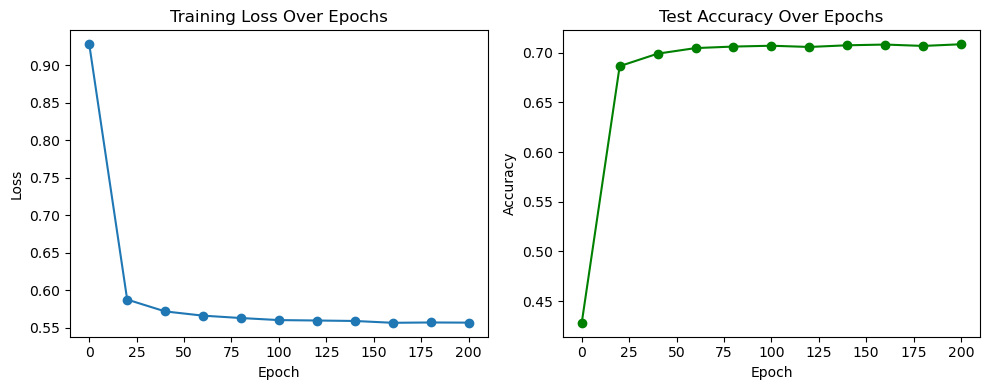

In [59]:
import matplotlib.pyplot as plt

# After training:
epochs = list(range(0, 201, 20))  # should be same length as losses & accuracies
if len(losses) < len(epochs):  # just in case you missed the final epoch
    epochs = epochs[:len(losses)] # populate this during training

plt.figure(figsize=(10, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracies, marker='o', color='green')
plt.title("Test Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()


In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# Load 2016 and 2023 building graphs
print("Loading graph data...")
with open("/Users/rachnarawalpally/Dakar_networks/output/building_network_2016.pkl", "rb") as f:
    G_2016 = pickle.load(f)
with open("/Users/rachnarawalpally/Dakar_networks/output/building_network_2023.pkl", "rb") as f:
    G_2023 = pickle.load(f)

Loading graph data...


In [4]:
# Convert to DataFrames
df_2016 = pd.DataFrame.from_dict(dict(G_2016.nodes(data=True)), orient='index')
df_2023 = pd.DataFrame.from_dict(dict(G_2023.nodes(data=True)), orient='index')

In [5]:
# Merge 2023 height into 2016 data
df_2016['mean_height_2023'] = df_2023['mean_height']

# Compute label: did height increase > 1m?
df_2016['height_change'] = df_2016['mean_height_2023'] - df_2016['mean_height']
df_2016['label'] = (df_2016['height_change'] > 1.0).astype(int)

In [6]:
# Basic feature engineering
feature_cols = ['mean_height', 'mean_presence', 'area']
df_2016[feature_cols] = df_2016[feature_cols].fillna(0)

# Add LandUseClass column to df_2016
df_2016['LandUseClass'] = pd.Series(nx.get_node_attributes(G_2016, 'LandUseClass'))

# One-hot encode land use classes
df_2016 = pd.get_dummies(df_2016, columns=['LandUseClass'])


In [7]:
# Graph-based features
print("Computing graph features...")
# Degree (number of neighbors)
degree_dict = dict(G_2016.degree())
df_2016['degree'] = pd.Series(degree_dict)

# Clustering coefficient
clustering_dict = nx.clustering(G_2016)
df_2016['clustering'] = pd.Series(clustering_dict)

# Update feature columns to include all features
feature_cols = ['mean_height', 'mean_presence', 'area', 'degree', 'clustering'] + \
               [col for col in df_2016.columns if col.startswith('LandUseClass_')]

print(f"Total features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")


Computing graph features...
Total features: 9
Feature columns: ['mean_height', 'mean_presence', 'area', 'degree', 'clustering', 'LandUseClass_Commercial', 'LandUseClass_Other', 'LandUseClass_Residential', 'LandUseClass_Unclassified Artificial Surfaces']


In [8]:
# Check for missing values and data quality
print(f"\nData quality check:")
print(f"Shape of features: {df_2016[feature_cols].shape}")
print(f"Missing values: {df_2016[feature_cols].isna().sum().sum()}")
print(f"Nodes match: {set(G_2016.nodes) == set(df_2016.index)}")


Data quality check:
Shape of features: (101789, 9)
Missing values: 0
Nodes match: True


In [8]:
# Class distribution analysis
print(f"\nClass distribution:")
print(f"Total samples: {len(df_2016)}")
print(f"Positive class (height increase): {df_2016['label'].sum()} ({df_2016['label'].mean():.3f})")
print(f"Negative class (no increase): {(df_2016['label'] == 0).sum()} ({(df_2016['label'] == 0).mean():.3f})")
print(f"Average height change: {df_2016['height_change'].mean():.2f}m")
print(f"Height change std: {df_2016['height_change'].std():.2f}m")

# Normalize features
print("\nNormalizing features...")
scaler = MinMaxScaler()
df_2016[feature_cols] = scaler.fit_transform(df_2016[feature_cols])

# Update graph with normalized features and labels
for n in G_2016.nodes():
    for col in feature_cols:
        G_2016.nodes[n][col] = float(df_2016.loc[n, col])
    G_2016.nodes[n]['label'] = int(df_2016.loc[n, 'label'])


Class distribution:
Total samples: 101789
Positive class (height increase): 41338 (0.406)
Negative class (no increase): 60451 (0.594)
Average height change: 0.45m
Height change std: 3.03m

Normalizing features...


In [10]:
# Check graph properties before conversion
print("Analyzing graph structure before conversion...")
num_nodes = G_2016.number_of_nodes()
num_edges = G_2016.number_of_edges()
avg_degree = 2 * num_edges / num_nodes if num_nodes > 0 else 0
density = 2 * num_edges / (num_nodes * (num_nodes - 1)) if num_nodes > 1 else 0

print(f"Graph analysis:")
print(f"  Nodes: {num_nodes:,}")
print(f"  Edges: {num_edges:,}")
print(f"  Average degree: {avg_degree:.1f}")
print(f"  Density: {density:.8f}")
print(f"  Expected conversion time: {'<2 min' if avg_degree < 50 else '2-10 min' if avg_degree < 200 else '>10 min (very dense)'}")


Analyzing graph structure before conversion...
Graph analysis:
  Nodes: 101,789
  Edges: 17,967
  Average degree: 0.4
  Density: 0.00000347
  Expected conversion time: <2 min


In [9]:
# Convert to PyTorch Geometric format
print("Converting to PyTorch Geometric format...")
data = from_networkx(G_2016)
data.x = torch.tensor(df_2016[feature_cols].values, dtype=torch.float32)
data.y = torch.tensor(df_2016['label'].values, dtype=torch.long)

print(f"Graph statistics:")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of features: {data.x.shape[1]}")
print(f"Is undirected: {data.is_undirected()}")

Converting to PyTorch Geometric format...
Graph statistics:
Number of nodes: 101789
Number of edges: 35934
Number of features: 9
Is undirected: True


: 

In [ ]:
data = from_networkx(G_2016)
data.x = torch.tensor(df_2016[feature_cols].values, dtype=torch.float32)
data.y = torch.tensor(df_2016['label'].values, dtype=torch.long)

In [1]:
# Enhanced train/test split with stratification
train_indices, test_indices = train_test_split(
    range(data.num_nodes), 
    test_size=0.2, 
    random_state=42, 
    stratify=data.y.numpy()
)

NameError: name 'train_test_split' is not defined

In [ ]:
# Create masks
train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[train_indices] = True
test_mask[test_indices] = True
# Validation split from training data
train_train_indices, val_indices = train_test_split(
    train_indices, 
    test_size=0.2, 
    random_state=42, 
    stratify=data.y[train_indices].numpy()
)

val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
val_mask[val_indices] = True
train_mask[val_indices] = False  # Remove validation from training

print(f"\nData splits:")
print(f"Training: {train_mask.sum()} ({train_mask.float().mean():.3f})")
print(f"Validation: {val_mask.sum()} ({val_mask.float().mean():.3f})")
print(f"Test: {test_mask.sum()} ({test_mask.float().mean():.3f})")
print(f"Train positive ratio: {data.y[train_mask].float().mean():.3f}")
print(f"Val positive ratio: {data.y[val_mask].float().mean():.3f}")
print(f"Test positive ratio: {data.y[test_mask].float().mean():.3f}")


In [ ]:
# Compute class weights for imbalanced data
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(data.y[train_mask].numpy()), 
    y=data.y[train_mask].numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print(f"Class weights: {class_weights}")

In [ ]:
# Enhanced GCN model with dropout and batch normalization
class EnhancedGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3, num_layers=2):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        
        # First layer
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        
        # Additional layers
        self.convs = torch.nn.ModuleList()
        self.bns = torch.nn.ModuleList()
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(torch.nn.BatchNorm1d(hidden_channels))
        
        # Final layer
        self.conv_final = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # First layer
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Additional layers
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Final layer (no activation, no dropout)
        x = self.conv_final(x, edge_index)
        return x



In [ ]:
def evaluate_model(model, data, mask, verbose=True):
    """Evaluate model performance on given mask"""
    model.eval()
    with torch.no_grad():
        logits = model(data)
        pred = logits.argmax(dim=1)
        
        # Basic metrics
        correct = (pred[mask] == data.y[mask]).sum().item()
        accuracy = correct / mask.sum().item()
        
        # Probabilities for AUC
        probs = F.softmax(logits, dim=1)[:, 1]  # Probability of positive class
        try:
            auc = roc_auc_score(data.y[mask].cpu().numpy(), probs[mask].cpu().numpy())
        except:
            auc = 0.0  # In case of issues with AUC calculation
        
        if verbose:
            print(f"Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
            print(classification_report(
                data.y[mask].cpu().numpy(), 
                pred[mask].cpu().numpy(),
                target_names=['No increase', 'Height increase'],
                zero_division=0
            ))
        
        return accuracy, auc, pred[mask].cpu().numpy()



In [ ]:
# Model setup
model = EnhancedGCN(
    in_channels=data.x.shape[1], 
    hidden_channels=32,  # Increased from 16
    out_channels=2,
    dropout=0.3,
    num_layers=3  # Increased depth
)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print(f"\nModel architecture:")
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

# Training loop with validation
print("\nStarting training...")
best_val_acc = 0
best_val_epoch = 0
patience = 50
no_improve_count = 0

train_losses = []
val_accs = []

for epoch in range(500):
    # Training
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    train_losses.append(loss.item())
    
    # Validation
    if epoch % 10 == 0 or epoch == 499:
        model.eval()
        with torch.no_grad():
            val_out = model(data)
            val_pred = val_out.argmax(dim=1)
            val_correct = (val_pred[val_mask] == data.y[val_mask]).sum().item()
            val_acc = val_correct / val_mask.sum().item()
            val_accs.append(val_acc)
            
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Val Acc: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")
            
            # Early stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_val_epoch = epoch
                no_improve_count = 0
                # Save best model
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                no_improve_count += 1
                
            if no_improve_count >= patience:
                print(f"Early stopping at epoch {epoch}. Best validation accuracy: {best_val_acc:.4f} at epoch {best_val_epoch}")
                break


In [ ]:
model.load_state_dict(torch.load('best_model.pth'))

# Final evaluation
print(f"\n{'='*50}")
print("FINAL EVALUATION RESULTS")
print(f"{'='*50}")

print(f"\nBest validation accuracy: {best_val_acc:.4f} at epoch {best_val_epoch}")

print(f"\nValidation Set Performance:")
val_acc, val_auc, val_pred = evaluate_model(model, data, val_mask)

print(f"\nTest Set Performance:")
test_acc, test_auc, test_pred = evaluate_model(model, data, test_mask)

# Confusion matrices
print(f"\nValidation Confusion Matrix:")
print(confusion_matrix(data.y[val_mask].cpu().numpy(), val_pred))

print(f"\nTest Confusion Matrix:")
print(confusion_matrix(data.y[test_mask].cpu().numpy(), test_pred))

# Feature importance analysis (if you want to understand which features matter most)
print(f"\nFeature importance analysis:")
print(f"Features used: {feature_cols}")
print(f"First layer weights shape: {model.conv1.weight.shape}")

# Save results
results = {
    'best_val_accuracy': best_val_acc,
    'best_val_epoch': best_val_epoch,
    'test_accuracy': test_acc,
    'test_auc': test_auc,
    'val_accuracy': val_acc,
    'val_auc': val_auc,
    'feature_columns': feature_cols,
    'class_distribution': data.y.bincount().tolist(),
    'model_params': sum(p.numel() for p in model.parameters())
}

print(f"\nFinal Results Summary:")
for key, value in results.items():
    print(f"{key}: {value}")

print(f"\nTraining completed successfully!")